# 🕰️🤖 TimesFM — Foundation Model for Time‑Series Forecasting

**TimesFM** is a *foundation model* for time-series: you feed it a recent **context window** of values and it **generates the future** (the forecast). Because it’s pretrained on many series, it can capture common patterns and produce **probabilistic outputs** (e.g., P10/P50/P90) by sampling. Think of it as a general-purpose forecaster you steer with a few knobs—**context length**, **horizon**, **number of samples**, and device/precision (CPU/GPU, bfloat16/float16).


**What you'll learn**
- 🧠 What **TimesFM** does (foundation model pre‑trained on many series)  
- 📥 Data prep: context window & forecast horizon  
- 📏 Scaling/standardization and inverse transform  
- ⚙️ Inference knobs (samples, quantiles)  
- 🖥️ Devices/precision (CPU/GPU/bfloat16/float16)  
- 📊 Plots & diagnostics, 📏 metrics & backtesting

## 🛠️ Setup & Imports

We use **PyTorch/NumPy** for arrays/devices and the **TimesFM** API for inference.  
Pin library versions (especially `torch`/CUDA) for reproducibility.

In [ ]:
import sys; print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [ ]:
!pip uninstall -y torch torchvision torchaudio transformers
!pip install --no-cache-dir \
  torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
  --index-url https://download.pytorch.org/whl/cpu
!pip install --no-cache-dir "transformers==4.44.2" accelerate

In [ ]:
!pip install --no-cache-dir "transformers>=4.45" accelerate

## 📏 Metrics

- Point: **MAE**, **RMSE**, **MAPE**  
- Probabilistic: **Pinball loss**, **CRPS**, **coverage** of P10–P90  
Always compare against strong baselines (**Lag‑7**, **LR/RF/SVR**, **Prophet**).

## 📊 Visualization & Diagnostics

Plot **actual vs P50** with a **P10–P90** band; inspect residuals over time and error by **hour/DoW/temp** to expose missed structure.

In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from transformers import TimesFmModelForPrediction

import warnings
warnings.filterwarnings('ignore')

# Read datasets

## 📥 Load & Prepare Data

- Parse timestamps to **DatetimeIndex**  
- Ensure a fixed **frequency** (e.g., hourly `H`)  
- Document units (e.g., **kW**, **kWh**) and the time window (start/end)

## 🕒 Time Index & Frequency

Keep a regular grid and consistent timezone (often **UTC**).  
Resolve DST gaps/overlaps before modeling.

In [ ]:
dataset = pd.read_csv('data/kaggle_competition_dataset.csv',
            parse_dates=['time'])
dataset.set_index('time', inplace=True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8592 entries, 2021-09-01 00:00:00 to 2022-08-24 23:00:00
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temp         8592 non-null   float64
 1   dwpt         8592 non-null   float64
 2   rhum         8592 non-null   float64
 3   prcp         2159 non-null   float64
 4   snow         119 non-null    float64
 5   wdir         8592 non-null   float64
 6   wspd         8592 non-null   float64
 7   wpgt         8592 non-null   float64
 8   pres         8592 non-null   float64
 9   coco         8396 non-null   float64
 10  el_price     8592 non-null   float64
 11  consumption  8592 non-null   float64
dtypes: float64(12)
memory usage: 872.6 KB


# Features


In [ ]:
demand = dataset[['consumption']]
demand = demand.rename(columns = {'consumption':'demand'})
demand.tail()

,demand
time,
2022-08-24 19:00:00,0.678
2022-08-24 20:00:00,0.457
2022-08-24 21:00:00,0.500
2022-08-24 22:00:00,2.321
2022-08-24 23:00:00,0.678


## Forecast

## 🧰 Context vs Horizon (Core Idea)

- **Context length**: how much history you pass in  
- **Horizon (prediction_length)**: how many steps ahead to forecast  
Align these with your operational use‑case (e.g., day‑ahead = 24 steps hourly).

## 🤖 TimesFM in Simple Words

**TimesFM** is a **pretrained foundation model** for time series.  
You feed the recent history (**context**), it **generates future values**; sampling can give **probabilistic** forecasts and **quantiles** (P10/P50/P90).

## 🖥️ Devices & Precision

Use **GPU (`cuda`)** if available; CPU works but slower.  
Mixed precision (**bfloat16/float16**) can speed up inference—verify numerical stability after switching.

TimesFM (univariate)
MAPE: 59.100 MAE: 0.339 RMSE: 0.465


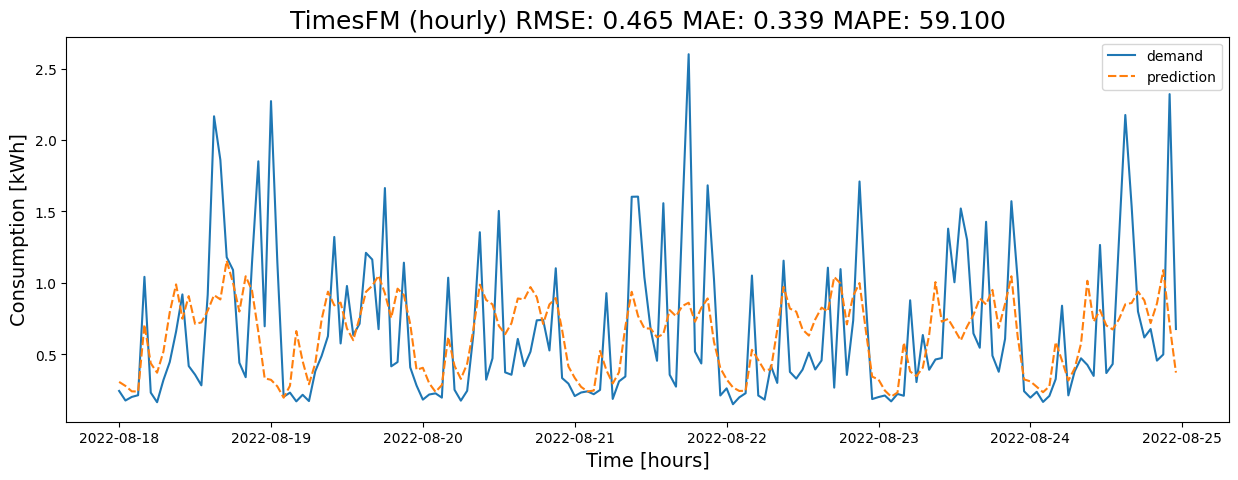

In [ ]:

FREQ = "H"
SAMPLES_PER_DAY = 24
predict_days = 7
training_data_length = 28

last_dataset_day = dataset.index.max().date()
prediction_start = pd.to_datetime(last_dataset_day - pd.Timedelta(days=predict_days-1))


def _timesfm_forecast_steps(model, context_values: np.ndarray, steps: int, freq_category: int = 0):
    """Forecast `steps` points, chunking if model.config.horizon_length < steps."""
    device = model.device
    dtype  = model.dtype
    try:
        per_call = int(model.config.horizon_length)
    except Exception:
        per_call = 128  # safe default

    ctx = torch.tensor(context_values, dtype=dtype, device=device)
    out_all = []
    remaining = steps
    while remaining > 0:
        this_call = min(remaining, per_call)
        with torch.no_grad():
            out = model(
                past_values=[ctx],
                freq=torch.tensor([freq_category], dtype=torch.long, device=device),
                return_dict=True,
            )
        yhat = out.mean_predictions[0][:this_call]
        out_all.append(yhat.detach())
        ctx = torch.cat([ctx, yhat], dim=0)
        remaining -= this_call
    return torch.cat(out_all, dim=0).float().cpu().numpy()


def rolling_timesfm_forecast():


    # Ensure DatetimeIndex & sorted, and hourly cadence
    df = demand.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    # Drop duplicate timestamps if any
    df = df[~df.index.duplicated(keep="last")]
    y_all = df["demand"].asfreq(FREQ).ffill().bfill()

    actual_full = pd.DataFrame()
    forecast_full = pd.DataFrame()

    for d in range(predict_days):
        predict_for_start = prediction_start + pd.Timedelta(days=d)
        predict_for_end   = predict_for_start + pd.Timedelta(days=1)

        training_end   = predict_for_start - pd.Timedelta(seconds=1)
        training_start = training_end - pd.Timedelta(days=training_data_length) + pd.Timedelta(seconds=1)

        # Slices
        y_train = y_all.loc[training_start:training_end]
        y_test  = y_all.loc[predict_for_start:predict_for_end - pd.Timedelta(seconds=1)]

        if len(y_train) < training_data_length * SAMPLES_PER_DAY or len(y_test) == 0:
            continue

        # Forecast exactly 1 day (24 steps hourly)
        yhat_np = _timesfm_forecast_steps(
            model,
            context_values=y_train.to_numpy(dtype=np.float32),
            steps=SAMPLES_PER_DAY,
            freq_category=0,  # high-frequency (hourly / 15-min / daily)
        )
        yhat = pd.Series(yhat_np, index=y_test.index, name="prediction")

        actual_full = pd.concat([actual_full, y_test.rename("demand").to_frame()])
        forecast_full = pd.concat([forecast_full, yhat.to_frame()])


    idx = actual_full.index.intersection(forecast_full.index)
    mae  = mean_absolute_error(actual_full.loc[idx, "demand"], forecast_full.loc[idx, "prediction"])
    mape = mean_absolute_percentage_error(actual_full.loc[idx, "demand"], forecast_full.loc[idx, "prediction"])
    rmse = np.sqrt(mean_squared_error(actual_full.loc[idx, "demand"], forecast_full.loc[idx, "prediction"]))

    mapestring = f"MAPE: {mape*100:.3f}"
    maestring  = f"MAE: {mae:.3f}"
    rmsestring = f"RMSE: {rmse:.3f}"

    plt.figure(figsize=(15,5))
    p = sns.lineplot(data=actual_full.join(forecast_full))
    plt.title(f"TimesFM (hourly) {rmsestring} {maestring} {mapestring}", fontsize=18)
    p.set_xlabel("Time [hours]", fontsize=14)
    p.set_ylabel("Consumption [kWh]", fontsize=14)
    # plt.show()

    print("TimesFM (univariate)")
    print(mapestring, maestring, rmsestring)

    return actual_full, forecast_full

actual_full, forecast_full = rolling_timesfm_forecast()
